# An implementation of Adaptive Bayesian Neural Networks (ABNN) for a basic CNN image classifier on CIFAR-10 dataset

## Import libraries and datasets

In [1]:
import random
random.seed(42)
!pip install netcal
!pip install torchsummary

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import time
import numpy as np
from torchsummary import summary
from torch.nn.functional import softmax
import torch.nn.functional as F
import netcal.metrics as metrics
from netcal.metrics import ECE
from sklearn.metrics import precision_recall_curve, auc, roc_auc_score, roc_curve, f1_score
import multiprocessing
multiprocessing.set_start_method('spawn', force=True)
import os
os.environ["MKL_THREADING_LAYER"] = "GNU"
from torch.utils.data import DataLoader

In [3]:
from loss_functions import ABNNLoss, CustomMAPLoss
import cnn
import cifar10, cifar100
import train
import test_and_eval
import resnet
from bnl import BNL
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


### Load and Augment CIFAR-10

In [5]:
trainloader, validloader, testloader = cifar10.get_data()

CIFAR10 Training set size: 40000
CIFAR10 Validation set size: 10000
CIFAR10 Test set size: 10000


##  Train the base model and save the weights

### Train the base CNN model, model codes have been stored in the cnn.py file

For the training of our base model, we use standard image classification methods: standard cross-entropy loss and SGD

cuda:0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
       BatchNorm2d-5           [-1, 64, 16, 16]             128
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
       BatchNorm2d-8            [-1, 128, 8, 8]             256
         MaxPool2d-9            [-1, 128, 4, 4]               0
           Linear-10                  [-1, 256]         524,544
      BatchNorm1d-11                  [-1, 256]             512
           Linear-12                  [-1, 128]          32,896
      BatchNorm1d-13                  [-1, 128]             256
           Linear-14            

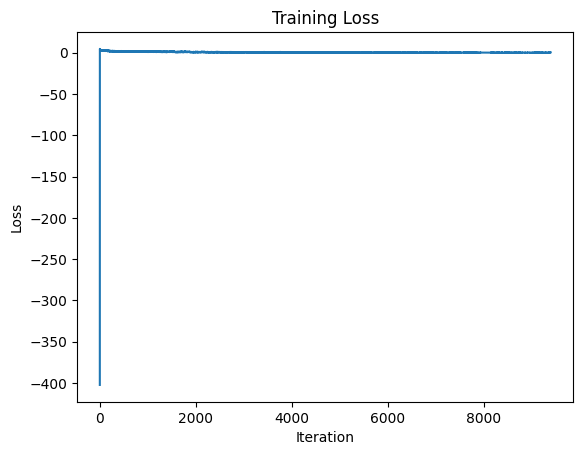

Accuracy of the network on the test images: 79.00 %
Saved the model weights


In [44]:
net = cnn.Net()
net.to(device)
train.train_model(model = net,
                  trainloader = trainloader,
                  testloader = testloader,
                  epochs = 30,
                  loss_type = 'CustomMAPLoss',
                  save_path = './trained_models/cifar_net.pth', debug = True)


In [45]:
test_and_eval.test_model_with_metrics(
        loss_fn=nn.CrossEntropyLoss(), 
        model=cnn.Net(), 
        test_loader=testloader, 
        load_path='./trained_models/cifar_net.pth',
        calculate_uncert=True, 
        calculate_nll_loss=True, 
        calculate_ece_error=True,
        calculate_auprc=True, 
        calculate_auc_roc=True, 
        calculate_fpr_95=True, 
        count_params=True,
        plot_uncert=False, 
        predict_uncert=False, 
        model_class=cnn.Net().__class__, 
        models=[torch.load('./trained_models/cifar_net.pth')],
        num_samples=10, 
        num_classes=10
    )


Test set Metrics:
  Average loss: 0.8626
  F1 Score: 0.7974
  Accuracy: 79.71%
  Uncertainties: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0}
  ECE: 0.1226
  Mean AUPR: 0.8757
  Mean AUC: 0.9762
  Mean FPR at 95% Recall: 0.1112
  Number of Parameters: 653194


In [48]:
torch.save(net.state_dict(), './trained_models/cifar_net.pth')

## Train the ABNN version with all normalisation layers replaced by BNL

### Training the new model

BNL model loaded from ./trained_models/cifar_net.pth
Model weights loaded.
cuda:0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
               BNL-2           [-1, 32, 32, 32]              64
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
               BNL-5           [-1, 64, 16, 16]             128
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
               BNL-8            [-1, 128, 8, 8]             256
         MaxPool2d-9            [-1, 128, 4, 4]               0
           Linear-10                  [-1, 256]         524,544
              BNL-11                  [-1, 256]             512
           Linear-12                  [-1, 128]          32,896
              BNL-13 

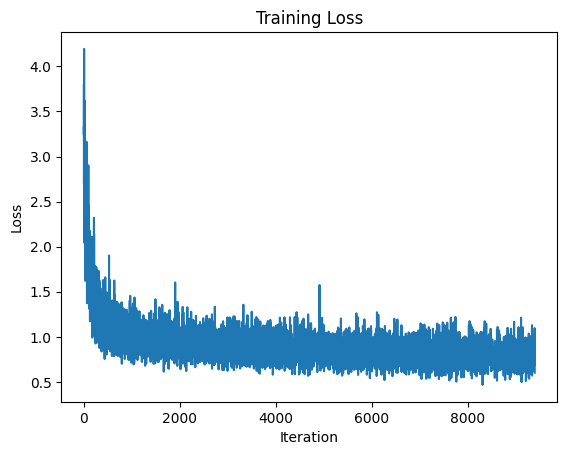

Accuracy of the network on the test images: 69.00 %
Saved the model weights


In [20]:
abnn = cnn.Net(norm_type = 'bnl')
abnn.to(device)
train.train_model(model = abnn,
                  trainloader = trainloader,
                  testloader = testloader,
                  epochs = 30,
                  loss_type = 'CrossEntropyLoss',
                  learning_rate = 0.0057,
                  BNL_enable = True,
                  save_path = './trained_models/cifar_abnn_net.pth',
                  load_path = './trained_models/cifar_net.pth',
                  debug = True,
                  strictness = True)


In [24]:
test_and_eval.test_model_with_metrics(
    loss_fn=nn.CrossEntropyLoss(), 
    model=cnn.Net(norm_type="bnl"), 
    test_loader=testloader, 
    load_path='./trained_models/cifar_abnn_net.pth',
    calculate_uncert=True, 
    calculate_nll_loss=True, 
    calculate_ece_error=True,
    calculate_auprc=True, 
    calculate_auc_roc=True, 
    calculate_fpr_95=True, 
    count_params=True,
    plot_uncert=True, 
    predict_uncert=True, 
    model_class=cnn.Net(norm_type="bnl").__class__, 
    models=[torch.load('./trained_models/cifar_abnn_net.pth')],
    num_samples=50, 
    num_classes=10,
    Weight_decay=5e-4
)


Test set Metrics:
  Average loss: 0.9283
  F1 Score: 0.7891
  Accuracy: 79.06%
  Uncertainties: {0: 0.04257945001974136, 1: 0.0404728592455953, 2: 0.043621559733454184, 3: 0.03183698437259167, 4: 0.04681134190505896, 5: 0.038686268856819674, 6: 0.042995772300622404, 7: 0.04027099907398224, 8: 0.04292505220333232, 9: 0.0434066591402277}
  ECE: 0.0266
  Mean AUPR: 0.7545
  Mean AUC: 0.9476
  Mean FPR at 95% Recall: 0.2348
  Number of Parameters: 653194


## Mixed ABNN with 2 layers made BNL

BNL model loaded from ./trained_models/cifar_net.pth
Model weights loaded.
cuda:0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
               BNL-5           [-1, 64, 16, 16]             128
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
               BNL-8            [-1, 128, 8, 8]             256
         MaxPool2d-9            [-1, 128, 4, 4]               0
           Linear-10                  [-1, 256]         524,544
              BNL-11                  [-1, 256]             512
           Linear-12                  [-1, 128]          32,896
              BNL-13 

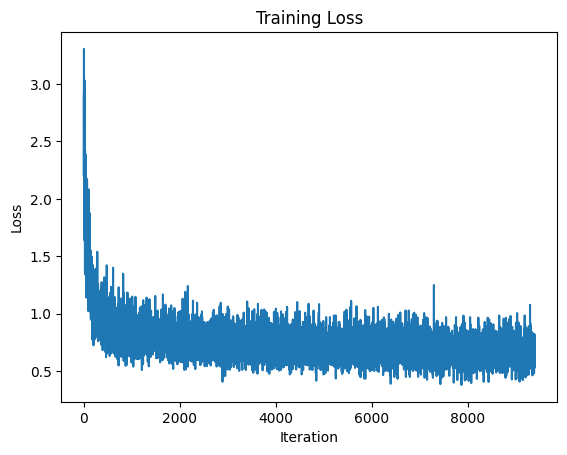

Accuracy of the network on the test images: 72.00 %
Saved the model weights


In [14]:
abnn_mixed = cnn.ABNN_mixed(norm_type = "bnl")
abnn_mixed.to(device)
train.train_model(model = abnn_mixed,
                  trainloader = trainloader,
                  testloader = testloader,
                  epochs = 30,
                  loss_type = 'CrossEntropyLoss',
                  learning_rate = 0.01,
                  BNL_enable = True,
                  save_path = './trained_models/cifar_abnn_nixed_net.pth',
                  load_path = './trained_models/cifar_net.pth',
                  debug = True,
                  strictness = False)

In [11]:
test_and_eval.test_model_with_metrics(
    loss_fn=nn.CrossEntropyLoss(), 
    model=cnn.ABNN_mixed(norm_type = "bnl"), 
    test_loader=testloader, 
    load_path='./trained_models/cifar_abnn_nixed_net.pth',
    calculate_uncert=True, 
    calculate_nll_loss=True, 
    calculate_ece_error=True,
    calculate_auprc=True, 
    calculate_auc_roc=True, 
    calculate_fpr_95=True, 
    count_params=True,
    plot_uncert=True, 
    predict_uncert=True, 
    model_class=cnn.ABNN_mixed(norm_type = "bnl").__class__, 
    models=[torch.load('./trained_models/cifar_abnn_nixed_net.pth')],
    num_samples=50, 
    num_classes=10,
    Weight_decay=5e-4
)


Test set Metrics:
  Average loss: 0.8340
  F1 Score: 0.8079
  Accuracy: 80.84%
  Uncertainties: {0: 0.04471761872402475, 1: 0.03207513018027891, 2: 0.0453109419374149, 3: 0.03328469775239878, 4: 0.04553613506066494, 5: 0.03575009015636354, 6: 0.038993081651054896, 7: 0.03759909435352193, 8: 0.03364266879573653, 9: 0.03921901169591225}
  ECE: 0.0396
  Mean AUPR: 0.7950
  Mean AUC: 0.9578
  Mean FPR at 95% Recall: 0.1989
  Number of Parameters: 653194


## Random Prior tests on Different Models (ABNN + DNN)

cuda:0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
       BatchNorm2d-2           [-1, 32, 32, 32]              64
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
       BatchNorm2d-5           [-1, 64, 16, 16]             128
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
       BatchNorm2d-8            [-1, 128, 8, 8]             256
         MaxPool2d-9            [-1, 128, 4, 4]               0
           Linear-10                  [-1, 256]         524,544
      BatchNorm1d-11                  [-1, 256]             512
           Linear-12                  [-1, 128]          32,896
      BatchNorm1d-13                  [-1, 128]             256
           Linear-14            

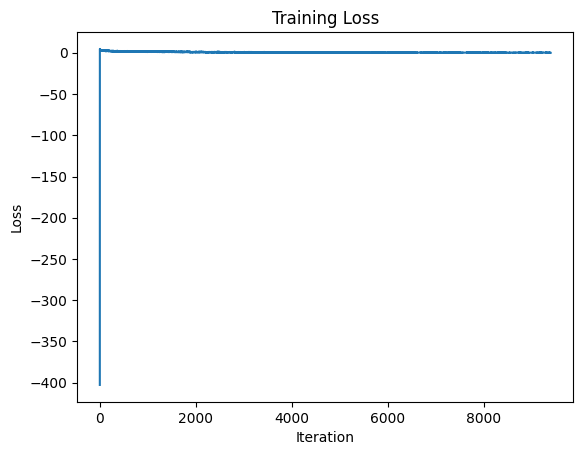

Accuracy of the network on the test images: 78.00 %
Saved the model weights


In [10]:
net = cnn.Net()
net.to(device)
train.train_model(model = net,
                  trainloader = trainloader,
                  testloader = testloader,
                  epochs = 30,
                  loss_type = 'CustomMAPLoss',
                  save_path = './trained_models/cifar_net_random_prior.pth', debug = True, random_prior = True)

In [20]:
test_and_eval.test_model_with_metrics(
        loss_fn=nn.CrossEntropyLoss(), 
        model=cnn.Net(), 
        test_loader=testloader, 
        load_path='./trained_models/cifar_net_random_prior.pth',
        calculate_uncert=True, 
        calculate_nll_loss=True, 
        calculate_ece_error=True,
        calculate_auprc=True, 
        calculate_auc_roc=True, 
        calculate_fpr_95=True, 
        count_params=True,
        plot_uncert=False, 
        predict_uncert=False, 
        model_class=cnn.Net().__class__, 
        models=[torch.load('./trained_models/cifar_net_random_prior.pth')],
        num_samples=50, 
        num_classes=10
    )


Test set Metrics:
  Average loss: 0.8644
  F1 Score: 0.7930
  Accuracy: 79.28%
  Uncertainties: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 0.0, 5: 0.0, 6: 0.0, 7: 0.0, 8: 0.0, 9: 0.0}
  ECE: 0.1222
  Mean AUPR: 0.8725
  Mean AUC: 0.9757
  Mean FPR at 95% Recall: 0.1190
  Number of Parameters: 653194


### All Layers BNL Random Prior:

BNL model loaded from ./trained_models/cifar_net_random_prior.pth
Model weights loaded.
cuda:0
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 32, 32]             896
               BNL-2           [-1, 32, 32, 32]              64
         MaxPool2d-3           [-1, 32, 16, 16]               0
            Conv2d-4           [-1, 64, 16, 16]          18,496
               BNL-5           [-1, 64, 16, 16]             128
         MaxPool2d-6             [-1, 64, 8, 8]               0
            Conv2d-7            [-1, 128, 8, 8]          73,856
               BNL-8            [-1, 128, 8, 8]             256
         MaxPool2d-9            [-1, 128, 4, 4]               0
           Linear-10                  [-1, 256]         524,544
              BNL-11                  [-1, 256]             512
           Linear-12                  [-1, 128]          32,896
        

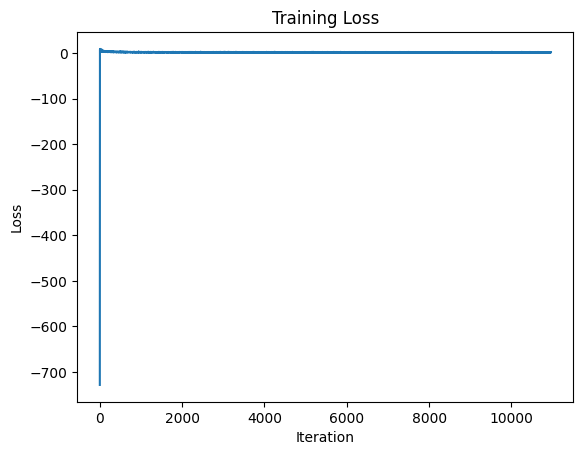

Accuracy of the network on the test images: 67.00 %
Saved the model weights

Test set Metrics:
  Average loss: 0.9501
  F1 Score: 0.6844
  Accuracy: 68.24%
  Uncertainties: {0: 0.044794194211688225, 1: 0.04923235983410968, 2: 0.04069821996307826, 3: 0.036016569767571706, 4: 0.045396298790971436, 5: 0.03927467624314978, 6: 0.04689409509778787, 7: 0.0360933393239975, 8: 0.03622853688754236, 9: 0.03930225294943039}
  ECE: 0.0414
  Mean AUPR: 0.7567
  Mean AUC: 0.9474
  Mean FPR at 95% Recall: 0.2436
  Number of Parameters: 653194


In [25]:
abnn = cnn.Net(norm_type = 'bnl')
abnn.to(device)
train.train_model(model = abnn,
                  trainloader = trainloader,
                  testloader = testloader,
                  epochs = 35,
                  loss_type = 'CustomMAPLoss',
                  learning_rate = 0.0057,
                  BNL_enable = True,
                  save_path = './trained_models/abnn_net__random_prior.pth',
                  load_path = './trained_models/cifar_net_random_prior.pth',
                  debug = True,
                  strictness = True, random_prior = True)
test_and_eval.test_model_with_metrics(
        loss_fn=nn.CrossEntropyLoss(), 
        model=cnn.Net(norm_type = 'bnl'), 
        test_loader=testloader, 
        load_path='./trained_models/abnn_net__random_prior.pth',
        calculate_uncert=True, 
        calculate_nll_loss=True, 
        calculate_ece_error=True,
        calculate_auprc=True, 
        calculate_auc_roc=True, 
        calculate_fpr_95=True, 
        count_params=True,
        plot_uncert=False, 
        predict_uncert=False, 
        model_class=cnn.Net(norm_type = 'bnl').__class__, 
        models=[torch.load('./trained_models/abnn_net__random_prior.pth')],
        num_samples=50, 
        num_classes=10
    )

## Variation of Results w.r.t the number of samples used to make prediction

In [37]:
accuracies = [] 
auprs = [] 
eces = [] 
aucs = []
fprs = []
f1s = []
for i in range(1, 50):
    test_model_with_metrics_temp(
    loss_fn=nn.CrossEntropyLoss(), 
    model=cnn.Net(norm_type="bnl"), 
    test_loader=testloader, 
    load_path='./trained_models/cifar_abnn_net.pth',
    calculate_uncert=True, 
    calculate_nll_loss=True, 
    calculate_ece_error=True,
    calculate_auprc=True, 
    calculate_auc_roc=True, 
    calculate_fpr_95=True, 
    count_params=True,
    plot_uncert=True, 
    predict_uncert=True, 
    model_class=cnn.Net(norm_type="bnl").__class__, 
    models=[torch.load('./trained_models/cifar_abnn_net.pth')],
    num_samples=i, 
    num_classes=10,
    Weight_decay=5e-4
    )

/tmp/ipykernel_68419/201588702.py:129: UserWarning: var(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1839.)
  variance = probabilities.var(dim=0)


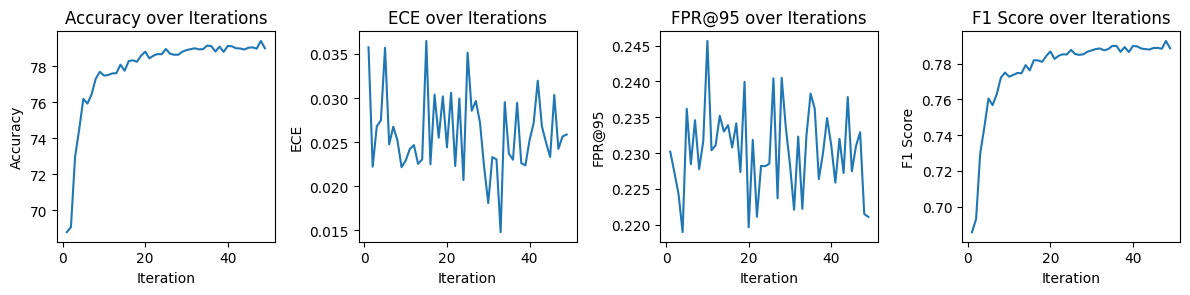

In [53]:
x = list(range(1, 50))  # x-axis values (iterations)

plt.figure(figsize=(12, 8))

# Plot Accuracy
plt.subplot(3, 4, 1)
plt.plot(x, accuracies)
plt.title('Accuracy over Iterations')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')

# Plot ECE
plt.subplot(3, 4, 2)
plt.plot(x, eces)
plt.title('ECE over Iterations')
plt.xlabel('Iteration')
plt.ylabel('ECE')

# Plot FPR@95
plt.subplot(3, 4, 3)
plt.plot(x, fprs)
plt.title('FPR@95 over Iterations')
plt.xlabel('Iteration')
plt.ylabel('FPR@95')

# Plot F1 Score
plt.subplot(3, 4, 4)
plt.plot(x, f1s)
plt.title('F1 Score over Iterations')
plt.xlabel('Iteration')
plt.ylabel('F1 Score')

plt.tight_layout()
plt.show()

In [30]:
class ECE:
    def __init__(self, bins=10):
        self.bins = bins

    def measure(self, probs, labels):
        probs = np.array(probs)
        labels = np.array(labels)
        confidences = np.max(probs, axis=1)
        predictions = np.argmax(probs, axis=1)
        accuracies = (predictions == labels).astype(float)
        
        bin_boundaries = np.linspace(0, 1, self.bins + 1)
        bin_lowers = bin_boundaries[:-1]
        bin_uppers = bin_boundaries[1:]
        
        ece = 0
        for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
            in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
            prop_in_bin = np.mean(in_bin)
            if prop_in_bin > 0:
                accuracy_in_bin = np.mean(accuracies[in_bin])
                avg_confidence_in_bin = np.mean(confidences[in_bin])
                ece += prop_in_bin * np.abs(avg_confidence_in_bin - accuracy_in_bin)
        return ece

def test_model_with_metrics_temp(loss_fn: nn.Module, model: nn.Module, test_loader, load_path: str = 'vit_mnist.pth',
               calculate_uncert: bool = False, calculate_nll_loss: bool = False, calculate_ece_error: bool = False,
               calculate_auprc: bool = False, calculate_auc_roc: bool = False, calculate_fpr_95: bool = False, 
               count_params: bool = False, plot_uncert: bool = False, predict_uncert: bool = False, 
               model_class: type = None, models: list = None, num_samples: int = 40, num_classes: int = 10,
               Weight_decay: float = 5e-4) -> None:
    """
    Evaluates a model on a test dataset and computes various metrics.

    Args:
        loss_fn (nn.Module): Loss function (or "ABNN" for ABNNLoss).
        model (nn.Module): The model to evaluate.
        test_loader: DataLoader for the test dataset.
        load_path (str): Path to the pre-trained model weights.
        calculate_uncert (bool): Whether to calculate uncertainty per class.
        calculate_nll_loss (bool): Whether to calculate NLL loss (not implemented).
        calculate_ece_error (bool): Whether to calculate Expected Calibration Error (ECE).
        calculate_auprc (bool): Whether to calculate AUPRC.
        calculate_auc_roc (bool): Whether to calculate AUC-ROC.
        calculate_fpr_95 (bool): Whether to calculate FPR at 95% recall.
        count_params (bool): Whether to count model parameters.
        plot_uncert (bool): Whether to plot uncertainty (not implemented).
        predict_uncert (bool): Whether to use multiple stochastic passes for predictions.
        model_class (type): Class of the model (required if predict_uncert=True).
        models (list): List of model state dictionaries (required if predict_uncert=True).
        num_samples (int): Number of stochastic forward passes for uncertainty prediction.
        num_classes (int): Number of classes in the dataset.
        Weight_decay (float): Weight decay parameter (not used in this implementation).
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.load_state_dict(torch.load(load_path), strict=False)
    model.to(device)
    model.eval()

    # Set up the loss criterion
    if loss_fn == "ABNN":
        eta = torch.ones(num_classes)
        criterion = ABNNLoss(num_classes, model.parameters()).to(device)
    elif loss_fn == "CustomMAPLoss":
        eta = torch.ones(num_classes)
        criterion = CustomMAPLoss(eta, model.parameters()).to(device)
    else:
        criterion = loss_fn

    all_predictions = []
    all_labels = []
    test_loss = 0.0
    all_probs = []
    uncertainties = {i: [] for i in range(num_classes)} if calculate_uncert else None

    with torch.no_grad():
        for data in test_loader:
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            if predict_uncert:
                if model_class is None or models is None:
                    raise ValueError("model_class and models must be provided for uncertainty prediction.")

                # Ensemble with majority voting across models and stochastic passes
                batch_predictions = []
                for model_state_dict in models:
                    net = model_class(norm_type = 'bnl')
                    net.load_state_dict(model_state_dict, strict = True)
                    net.to(device)
                    net.eval()

                    # Run multiple stochastic forward passes
                    model_preds = []
                    for _ in range(num_samples):
                        outputs = net(inputs)
                        _, preds = torch.max(outputs, 1)
                        model_preds.append(preds)
                    # Take mode of predictions for this model
                    stacked_preds = torch.stack(model_preds)
                    mode_preds, _ = torch.mode(stacked_preds, dim=0)
                    batch_predictions.append(mode_preds)

                # Take mode across all models
                stacked_batch_preds = torch.stack(batch_predictions)
                final_preds, _ = torch.mode(stacked_batch_preds, dim=0)
            else:
                # Single forward pass without uncertainty prediction
                outputs = model(inputs)
                _, final_preds = torch.max(outputs, 1)

            # Compute loss
            outputs = model(inputs)  # Recompute outputs for loss and metrics
            test_loss += criterion(outputs, labels).item()

            # Collect predictions and labels
            all_predictions.append(final_preds.cpu())
            all_labels.append(labels.cpu())

            # Compute probabilities for other metrics
            if calculate_ece_error or calculate_auprc or calculate_auc_roc or calculate_fpr_95:
                probs = torch.softmax(outputs, dim=1)
                all_probs.append(probs.cpu().numpy())

            # Compute uncertainty if requested
            if calculate_uncert:
                mc_outputs = torch.stack([model(inputs) for _ in range(num_samples)])
                probabilities = torch.softmax(mc_outputs, dim=-1)
                variance = probabilities.var(dim=0)
                for i in range(num_classes):
                    class_mask = (labels == i)
                    if class_mask.any():
                        class_variance = variance[class_mask, i].mean().item()
                        uncertainties[i].append(class_variance)
                        
    

    # Concatenate all predictions and labels
    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)

    # Compute accuracy
    correct = (all_predictions == all_labels).sum().item()
    total = all_labels.size(0)
    accuracy = 100 * correct / total

    # Compute other metrics
    test_loss /= len(test_loader)
    all_preds_np = all_predictions.numpy()
    all_targets_np = all_labels.numpy()
    f1 = f1_score(all_targets_np, all_preds_np, average='weighted')

    avg_uncertainties = {i: np.mean(uncertainties[i]) if uncertainties[i] else 0 for i in range(num_classes)} if calculate_uncert else None

    all_probs = np.concatenate(all_probs, axis=0) if all_probs else None
    ece_score = ECE(bins=10).measure(all_probs, all_targets_np) if calculate_ece_error else None

    if calculate_auprc:
        auprs = []
        all_labels_one_hot = np.eye(num_classes)[all_targets_np]
        for i in range(num_classes):
            precision, recall, _ = precision_recall_curve(all_labels_one_hot[:, i], all_probs[:, i])
            aupr = auc(recall, precision)
            auprs.append(aupr)
        mean_aupr = np.mean(auprs)
    else:
        mean_aupr = None

    if calculate_auc_roc:
        aucs = []
        all_labels_one_hot = np.eye(num_classes)[all_targets_np]
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(all_labels_one_hot[:, i], all_probs[:, i])
            roc_auc = auc(fpr, tpr)
            aucs.append(roc_auc)
        mean_auc = np.mean(aucs)
    else:
        mean_auc = None

    if calculate_fpr_95:
        fpr_95_recall = []
        all_labels_one_hot = np.eye(num_classes)[all_targets_np]
        for i in range(num_classes):
            fpr, tpr, _ = roc_curve(all_labels_one_hot[:, i], all_probs[:, i])
            idx = np.where(tpr >= 0.95)[0][0]
            fpr_at_95_recall = fpr[idx]
            fpr_95_recall.append(fpr_at_95_recall)
        mean_fpr_95_recall = np.mean(fpr_95_recall)
    else:
        mean_fpr_95_recall = None

    param_count = sum(p.numel() for p in model.parameters() if p.requires_grad) if count_params else None

    # Print results
    # print(f'\nTest set Metrics:')
    # print(f'  Average loss: {test_loss:.4f}')
    # print(f'  F1 Score: {f1:.4f}')
    # print(f'  Accuracy: {accuracy:.2f}%')
    f1s.append(f1)
    accuracies.append(accuracy)
    eces.append(ece_score)
    aucs.append(mean_auc)
    auprs.append(mean_aupr)
    fprs.append(mean_fpr_95_recall)
    # if calculate_uncert:
    #     print(f'  Uncertainties: {avg_uncertainties}')
    # if calculate_ece_error:
    #     print(f'  ECE: {ece_score:.4f}')
    # if calculate_auprc:
    #     print(f'  Mean AUPR: {mean_aupr:.4f}')
    # if calculate_auc_roc:
    #     print(f'  Mean AUC: {mean_auc:.4f}')
    # if calculate_fpr_95:
    #     print(f'  Mean FPR at 95% Recall: {mean_fpr_95_recall:.4f}')
    # if count_params:
    #     print(f'  Number of Parameters: {param_count}')

## What if the model is tested without training on the new BNL Layers?

In [57]:
test = cnn.Net(norm_type = 'bnl')
test.to(device)
load_path = './trained_models/cifar_net.pth'
state_dict = torch.load(load_path, map_location = device)
filtered_state_dict = {k: v for k, v in state_dict.items() if 'running_mean' not in k and 'running_var' not in k and 'num_batches_tracked' not in k}
test.load_state_dict(filtered_state_dict, strict=False)
test.to(device)
torch.save(test.state_dict(), './trained_models/abnn_test.pth')
test_and_eval.test_model_with_metrics(
        loss_fn=nn.CrossEntropyLoss(), 
        model=cnn.Net(norm_type = 'bnl'), 
        test_loader=testloader, 
        load_path='./trained_models/abnn_test.pth',
        calculate_uncert=True, 
        calculate_nll_loss=True, 
        calculate_ece_error=True,
        calculate_auprc=True, 
        calculate_auc_roc=True, 
        calculate_fpr_95=True, 
        count_params=True,
        plot_uncert=False, 
        predict_uncert=False, 
        model_class=cnn.Net(norm_type = 'bnl').__class__, 
        models=[torch.load('./trained_models/abnn_test.pth')],
        num_samples=40, 
        num_classes=10
    )


Test set Metrics:
  Average loss: 3.9530
  F1 Score: 0.4031
  Accuracy: 40.00%
  Uncertainties: {0: 0.15523127475871315, 1: 0.16747999398768704, 2: 0.14688639040989213, 3: 0.147403565011447, 4: 0.1442057918279599, 5: 0.1471764403807966, 6: 0.15716336151728263, 7: 0.1544313542073286, 8: 0.16028996849361854, 9: 0.1612596855713771}
  ECE: 0.4436
  Mean AUPR: 0.3838
  Mean AUC: 0.8015
  Mean FPR at 95% Recall: 0.6854
  Number of Parameters: 653194
